# Commodities Prices (TTF, CO2, API2)
Daily prices for 2022-2025 from Yahoo Finance; saved to parquet and upsampled to hourly for merging.

In [20]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.Timestamp.utcnow = staticmethod(lambda: pd.Timestamp.now('UTC'))

START = '2022-01-01'
END = '2026-03-01'
DATA_DIR = Path('..') / 'data'
BASE_TICKERS = {
    'gas_price': 'TTF=F',
    'coal_price': 'MTF=F',
}
EUA_CANDIDATES = ['CO2.L', 'CHEC.SW', 'CBU2.DE', 'EUA=F', 'C02.F', 'CO2.DE', 'ECF2.EX']


In [21]:
def fetch_prices(start=START, end=END, interval='1d'):
    tickers = dict(BASE_TICKERS)
    frames = []
    eua_symbol = None
    for cand in EUA_CANDIDATES:
        test = yf.download(cand, start=start, end=end, interval=interval, auto_adjust=False, progress=False, group_by='column')
        if test.empty:
            continue
        cols = test.columns.get_level_values(0) if isinstance(test.columns, pd.MultiIndex) else test.columns
        if 'Adj Close' in cols:
            eua_symbol = cand
            break
    if eua_symbol:
        tickers['co2_price'] = eua_symbol
    else:
        print('Warning: no CO2 ticker returned data; skipping CO2 series.')

    for col_name, ticker in tickers.items():
        df = yf.download(ticker, start=start, end=end, interval=interval, auto_adjust=False, progress=False, group_by='column')
        if df.empty:
            print(f'Warning: no data for {ticker}')
            continue
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
        if 'Adj Close' not in df.columns:
            print(f'Warning: missing Adj Close for {ticker}; skipping.')
            continue
        df = df.reset_index().rename(columns={'Date': 'timestamp', 'Adj Close': col_name})
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
        df = df[['timestamp', col_name]].drop_duplicates(subset=['timestamp']).set_index('timestamp')
        frames.append(df)
    if not frames:
        return pd.DataFrame(columns=['timestamp'] + list(tickers.keys()))
    merged = pd.concat(frames, axis=1, sort=False).sort_index()
    merged = merged[~merged.index.duplicated(keep='last')].reset_index()
    return merged

def upsample_daily_to_hourly(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    start = df['timestamp'].min().floor('D')
    end = df['timestamp'].max().ceil('D')
    hourly_index = pd.date_range(start, end, freq='1h', tz='UTC')
    df = (
        df.sort_values('timestamp')
        .set_index('timestamp')
        .reindex(hourly_index, method='ffill')
        .reset_index()
        .rename(columns={'index': 'timestamp'})
    )
    return df


In [22]:
commodities_daily = fetch_prices()
commodities_hourly = upsample_daily_to_hourly(commodities_daily)
commodities_hourly.head()


,timestamp,gas_price,coal_price,co2_price
0,2022-01-03 00:00:00+00:00,80.433998,119.0,NaN
1,2022-01-03 01:00:00+00:00,80.433998,119.0,NaN
2,2022-01-03 02:00:00+00:00,80.433998,119.0,NaN
3,2022-01-03 03:00:00+00:00,80.433998,119.0,NaN
4,2022-01-03 04:00:00+00:00,80.433998,119.0,NaN


In [23]:
commodities_hourly.describe(include='all')


,timestamp,gas_price,coal_price,co2_price
count,34969,34393.000000,34296.000000,34369.000000
mean,2024-01-01 12:00:00+00:00,61.114552,157.351190,74.452734
min,2022-01-03 00:00:00+00:00,22.934000,89.250000,49.665001
25%,2023-01-02 06:00:00+00:00,32.689999,104.650002,67.169998
50%,2024-01-01 12:00:00+00:00,39.791000,117.949997,74.680000
75%,2024-12-30 18:00:00+00:00,72.314003,166.149994,82.250000
max,2025-12-30 00:00:00+00:00,339.196014,438.350006,96.415001
std,NaN,49.147419,85.947048,9.632287


In [ ]:
# Null summary
commodities_nulls = commodities_hourly.isna().sum()
commodities_nulls


In [24]:
# Save to parquet for merging
out_path = DATA_DIR / 'commodities.parquet'
out_path.parent.mkdir(parents=True, exist_ok=True)
if not commodities_hourly.empty:
    commodities_hourly.to_parquet(out_path, compression='zstd', index=False)
out_path


PosixPath('../data/commodities.parquet')

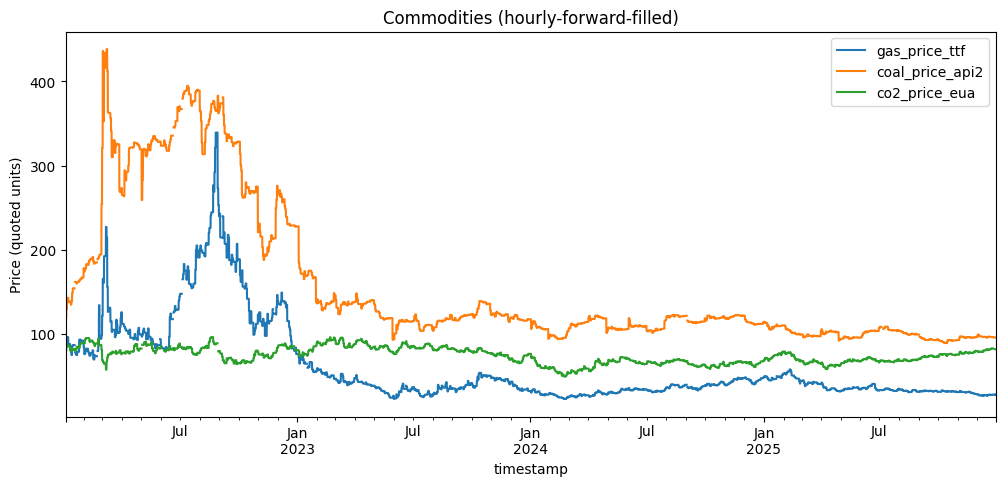

In [25]:
# Plot commodities
if not commodities_hourly.empty:
    ax = commodities_hourly.set_index('timestamp').plot(figsize=(12,5))
    ax.set_ylabel('Price (quoted units)')
    ax.set_title('Commodities (hourly-forward-filled)')
    plt.show()


## CO2 price (fallback tries)
Fallback tickers: CO2.L, CHEC.SW, CBU2.DE, EUA=F, C02.F, CO2.DE, ECF2.EX.


In [26]:
co2_frames = []
for t in EUA_CANDIDATES:
    df = yf.download(t, start=START, end=END, interval='1d', auto_adjust=False, progress=False, group_by='column')
    if df.empty:
        print(f'No data for {t}')
        continue
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    if 'Adj Close' not in df.columns:
        print(f'Missing Adj Close for {t}')
        continue
    tmp = df.reset_index().rename(columns={'Date':'timestamp','Adj Close':'co2_price'})
    tmp['timestamp'] = pd.to_datetime(tmp['timestamp'], utc=True)
    tmp['ticker'] = t
    co2_frames.append(tmp[['timestamp','co2_price','ticker']])

if co2_frames:
    co2_prices = pd.concat(co2_frames, ignore_index=True)
    co2_prices = co2_prices.sort_values('timestamp').drop_duplicates(subset=['timestamp'], keep='last')
else:
    co2_prices = pd.DataFrame(columns=['timestamp','co2_price','ticker'])
co2_prices.tail()


$CHEC.SW: possibly delisted; no timezone found

1 Failed download:
['CHEC.SW']: possibly delisted; no timezone found
$EUA=F: possibly delisted; no timezone found

1 Failed download:
['EUA=F']: possibly delisted; no timezone found
$C02.F: possibly delisted; no timezone found

1 Failed download:
['C02.F']: possibly delisted; no timezone found
$CO2.DE: possibly delisted; no timezone found

1 Failed download:
['CO2.DE']: possibly delisted; no timezone found
$ECF2.EX: possibly delisted; no timezone found

1 Failed download:
['ECF2.EX']: possibly delisted; no timezone found


No data for CHEC.SW
No data for EUA=F
No data for C02.F
No data for CO2.DE
No data for ECF2.EX


,timestamp,co2_price,ticker
1683,2025-12-22 00:00:00+00:00,5.426400,CBU2.DE
1684,2025-12-23 00:00:00+00:00,5.440000,CBU2.DE
1004,2025-12-24 00:00:00+00:00,82.809998,CO2.L
1685,2025-12-29 00:00:00+00:00,5.455400,CBU2.DE
1686,2025-12-30 00:00:00+00:00,5.444600,CBU2.DE


In [27]:
# Save CO2 parquet for merging if data exists
co2_path = DATA_DIR / 'co2_price.parquet'
if not co2_prices.empty:
    co2_prices.to_parquet(co2_path, compression='zstd', index=False)
co2_path


PosixPath('../data/co2_price.parquet')

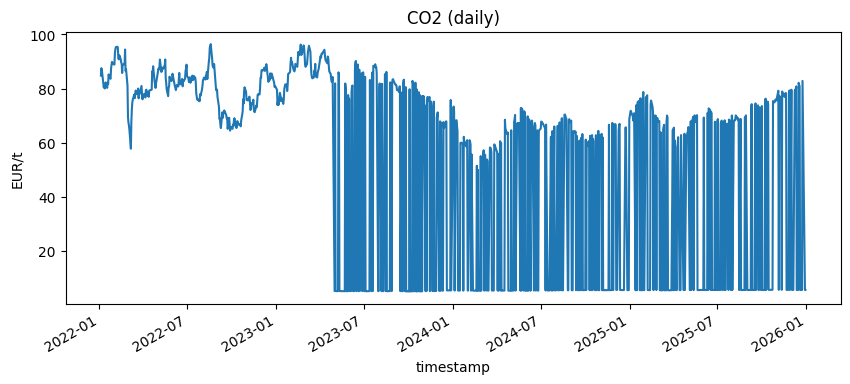

In [28]:
# Plot CO2 prices (daily + forward-fill to daily grid)
if not co2_prices.empty:
    co2_daily = (co2_prices.set_index('timestamp')
                 .resample('1D').ffill()
                 .reset_index())
    ax = co2_daily.set_index('timestamp')['co2_price'].plot(figsize=(10,4))
    ax.set_ylabel('EUR/t')
    ax.set_title('CO2 (daily, ffill)')
    plt.show()


## Notes / Cleaning hints
- Prices are daily; upsampled to hourly via forward fill to align with hourly datasets.
- Missing days (weekends/holidays) are expected.
- Outliers can occur; clip only if they break models.
- Parquets saved in ../data for merging.
